##1. Package Installation and Setup

In [1]:
import sys
import subprocess

def run_pip(*packages):
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", *packages
    ])

print("1/3 Removing unused torchvision...")
subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchvision"],
    check=False
)

print("2/3 Installing stable NLP packages...")
run_pip(
    "transformers==4.46.3",
    "sentencepiece>=0.2.0",
    "spacy>=3.7,<4",
    "seaborn>=0.13",
    "matplotlib>=3.8",
    "pandas>=2.2,<3"
)

print("3/3 Installing spaCy English model...")
subprocess.check_call([
    sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"
])

print()
print("Installation completed.")
print("IMPORTANT: Runtime -> Restart session")
print("Then continue with Cell 2.")

1/3 Removing unused torchvision...
2/3 Installing stable NLP packages...
3/3 Installing spaCy English model...

Installation completed.
IMPORTANT: Runtime -> Restart session
Then continue with Cell 2.


##2. Import Libraries and Verify Environment

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import torch
import transformers

from transformers import pipeline

print("Environment loaded successfully!")
print()
print("Python       :", sys.version.split()[0])
print("PyTorch      :", torch.__version__)
print("Pandas       :", pd.__version__)
print("Transformers :", transformers.__version__)
print("spaCy        :", spacy.__version__)
print("GPU available:", torch.cuda.is_available())

nlp = spacy.load("en_core_web_sm")
print("spaCy model  : en_core_web_sm")

Environment loaded successfully!

Python       : 3.13.16
PyTorch      : 2.11.0+cpu
Pandas       : 2.2.3
Transformers : 4.46.3
spaCy        : 3.8.16
GPU available: False
spaCy model  : en_core_web_sm


##3. Test Transformers Pipeline

In [3]:
TEST_MODEL = "distilbert-base-uncased-finetuned-sst-2-english"
DEVICE = 0 if torch.cuda.is_available() else -1

test_pipeline = pipeline(
    "sentiment-analysis",
    model=TEST_MODEL,
    device=DEVICE
)

result = test_pipeline("I love teaching artificial intelligence!")

print("Transformers pipeline is working!")
print("Device:", "GPU" if DEVICE == 0 else "CPU")
print(result)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Transformers pipeline is working!
Device: CPU
[{'label': 'POSITIVE', 'score': 0.9990171194076538}]


##4. Load Pretrained BERT Sentiment Model

In [4]:
MODEL_NAME = "textattack/bert-base-uncased-SST-2"
DEVICE = 0 if torch.cuda.is_available() else -1

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=DEVICE
)

print("BERT sentiment model loaded!")
print("Model:", MODEL_NAME)
print("Device:", "GPU" if DEVICE == 0 else "CPU")

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

BERT sentiment model loaded!
Model: textattack/bert-base-uncased-SST-2
Device: CPU


##5. Draw Conceptual BERT Pipeline Diagram

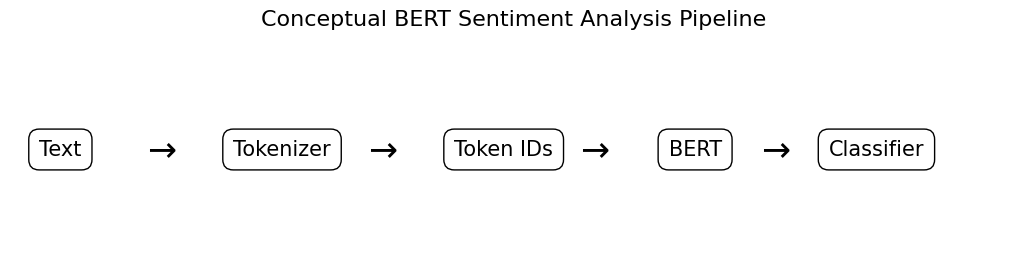

In [5]:
fig, ax = plt.subplots(figsize=(13, 3))
ax.axis("off")

boxes = [
    ("Text", 0.05),
    ("Tokenizer", 0.27),
    ("Token IDs", 0.49),
    ("BERT", 0.68),
    ("Classifier", 0.86)
]

for label, x in boxes:
    ax.text(
        x, 0.5, label,
        ha="center", va="center", fontsize=15,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black")
    )

for x in [0.16, 0.38, 0.59, 0.77]:
    ax.annotate("→", xy=(x + 0.035, 0.5), xytext=(x - 0.01, 0.5),
                fontsize=25, ha="center", va="center")

plt.title("Conceptual BERT Sentiment Analysis Pipeline", fontsize=16)
plt.show()

##6. Tokenization Demonstration

In [6]:
tokenizer = sentiment_pipeline.tokenizer
text = "I love this amazing chicken restaurant!"

tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print("Original text:")
print(text)

print("\nTokens:")
print(tokens)

print("\nToken IDs:")
print(token_ids)

print("\nSpecial-token version:")
print(tokenizer(text))

Original text:
I love this amazing chicken restaurant!

Tokens:
['i', 'love', 'this', 'amazing', 'chicken', 'restaurant', '!']

Token IDs:
[1045, 2293, 2023, 6429, 7975, 4825, 999]

Special-token version:
{'input_ids': [101, 1045, 2293, 2023, 6429, 7975, 4825, 999, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


##7. First BERT Sentiment Prediction

In [7]:
sentence = "I absolutely loved the food and the service."

result = sentiment_pipeline(sentence)[0]

print("Sentence:", sentence)
print("Predicted sentiment:", result["label"])
print("Confidence:", f"{result['score']:.2%}")

Sentence: I absolutely loved the food and the service.
Predicted sentiment: LABEL_1
Confidence: 99.96%


##8. Reusable Sentiment Prediction Function

In [8]:
def explain_sentiment(text):
    prediction = sentiment_pipeline(text)[0]
    print("Text:", text)
    print("Sentiment:", prediction["label"])
    print("Confidence:", f"{prediction['score']:.2%}")
    return prediction

explain_sentiment("The movie was fantastic!")

Text: The movie was fantastic!
Sentiment: LABEL_1
Confidence: 99.97%


{'label': 'LABEL_1', 'score': 0.9996718168258667}

##9. Classroom Experiment Batch Prediction

In [9]:
sentences = [
    "The food was delicious.",
    "The service was terrible.",
    "The movie was excellent.",
    "The product broke after one day.",
    "I really enjoyed the experience.",
    "I regret buying this product.",
    "The hotel room was clean and comfortable.",
    "The staff were rude and unhelpful."
]

rows = []
for text in sentences:
    prediction = sentiment_pipeline(text)[0]
    rows.append({
        "Text": text,
        "Sentiment": prediction["label"],
        "Confidence": prediction["score"]
    })

classroom_df = pd.DataFrame(rows)
classroom_df["Confidence %"] = (classroom_df["Confidence"] * 100).round(2)

display(classroom_df[["Text", "Sentiment", "Confidence %"]])

,Text,Sentiment,Confidence %
0,The food was delicious.,LABEL_1,99.95
1,The service was terrible.,LABEL_0,99.80
2,The movie was excellent.,LABEL_1,99.95
3,The product broke after one day.,LABEL_0,98.48
4,I really enjoyed the experience.,LABEL_1,99.96
5,I regret buying this product.,LABEL_0,99.84
6,The hotel room was clean and comfortable.,LABEL_1,99.92
7,The staff were rude and unhelpful.,LABEL_0,99.67


##10. Sentiment Confidence Visualization

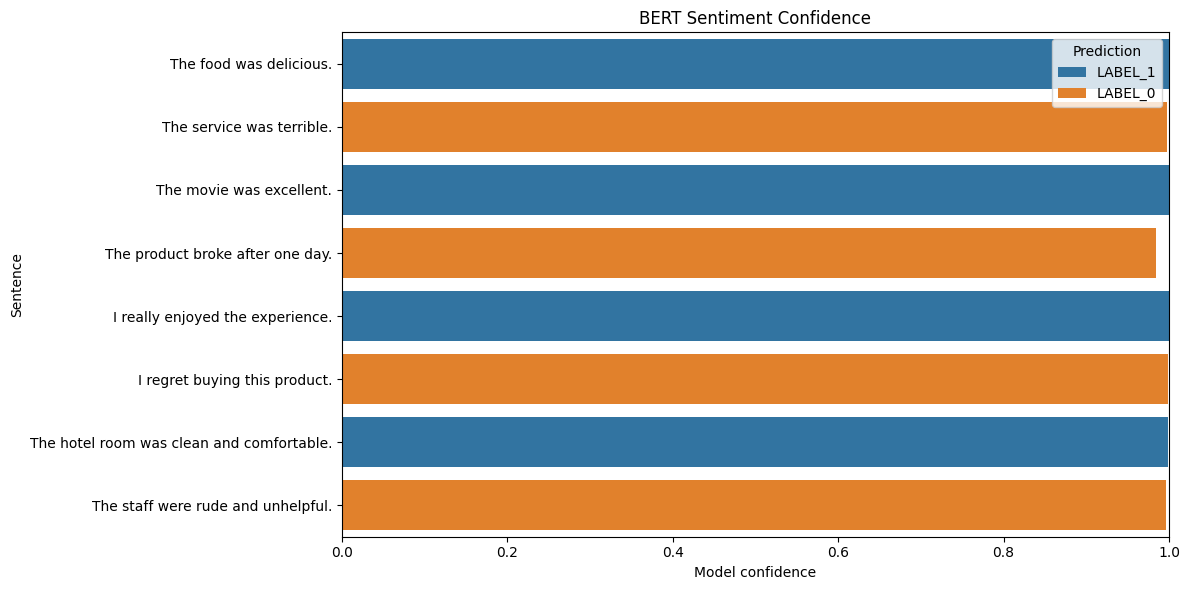

In [10]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=classroom_df,
    x="Confidence",
    y="Text",
    hue="Sentiment",
    dodge=False
)

plt.xlim(0, 1)
plt.xlabel("Model confidence")
plt.ylabel("Sentence")
plt.title("BERT Sentiment Confidence")
plt.legend(title="Prediction")
plt.tight_layout()
plt.show()

##11. Positive vs. Negative Sentiment Count Chart

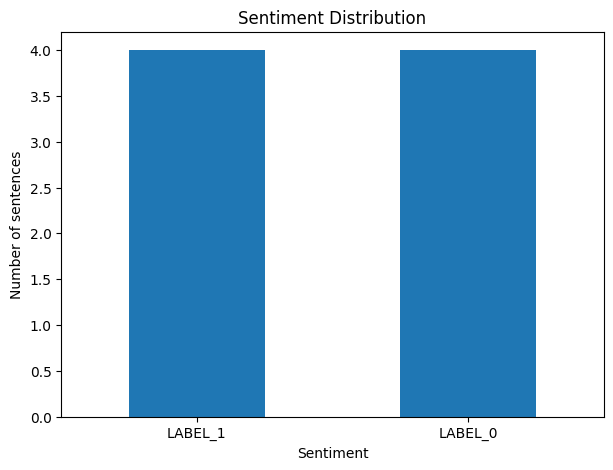

In [11]:
counts = classroom_df["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))
counts.plot(kind="bar")
plt.xlabel("Sentiment")
plt.ylabel("Number of sentences")
plt.title("Sentiment Distribution")
plt.xticks(rotation=0)
plt.show()

##12. Conceptual Attention Heatmap Visualization

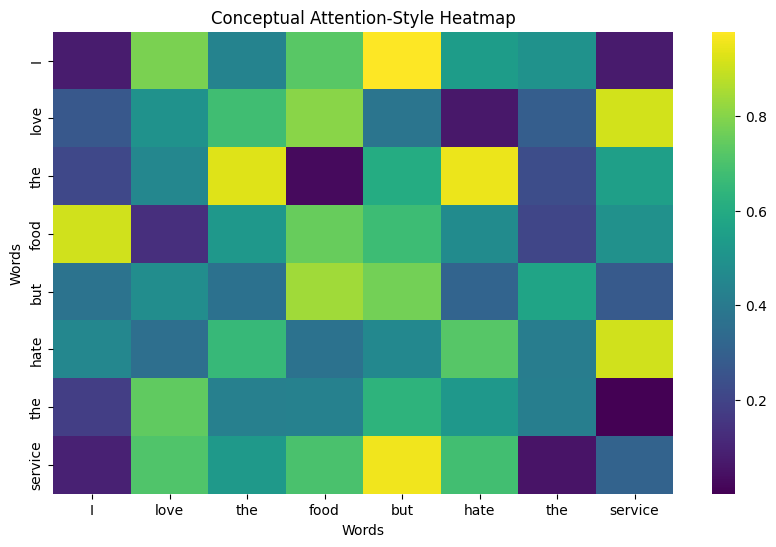

Educational visualization only - not actual BERT attention weights.


In [12]:
sentence = "I love the food but hate the service."
words = sentence.replace(".", "").split()

np.random.seed(7)
attention_demo = np.random.rand(len(words), len(words))

plt.figure(figsize=(10, 6))
sns.heatmap(
    attention_demo,
    xticklabels=words,
    yticklabels=words,
    cmap="viridis"
)

plt.title("Conceptual Attention-Style Heatmap")
plt.xlabel("Words")
plt.ylabel("Words")
plt.show()

print("Educational visualization only - not actual BERT attention weights.")

##13. Simplified BERT Architecture Summary

In [13]:
print("\n".join([
    "BERT-style architecture",
    "        ↓",
    "Input Text",
    "        ↓",
    "Tokenizer",
    "        ↓",
    "Token + Position Representations",
    "        ↓",
    "Transformer Encoder",
    "   ├── Self-Attention",
    "   ├── Feed-Forward Network",
    "   ├── Residual Connections",
    "   └── Layer Normalization",
    "        ↓",
    "Contextual Representation",
    "        ↓",
    "Classification Layer",
    "        ↓",
    "POSITIVE / NEGATIVE"
]))

BERT-style architecture
        ↓
Input Text
        ↓
Tokenizer
        ↓
Token + Position Representations
        ↓
Transformer Encoder
   ├── Self-Attention
   ├── Feed-Forward Network
   ├── Residual Connections
   └── Layer Normalization
        ↓
Contextual Representation
        ↓
Classification Layer
        ↓
POSITIVE / NEGATIVE


##14. Count Model Parameters

In [14]:
total_params = sum(p.numel() for p in sentiment_pipeline.model.parameters())
trainable_params = sum(
    p.numel() for p in sentiment_pipeline.model.parameters()
    if p.requires_grad
)

print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

print("\nTeaching point:")
print("A pretrained transformer contains many learned parameters.")
print("We can reuse those learned representations instead of training from scratch.")

Total parameters: 109,483,778
Trainable parameters: 109,483,778

Teaching point:
A pretrained transformer contains many learned parameters.
We can reuse those learned representations instead of training from scratch.


##15. Evaluate Tricky and Mixed Sentences

In [15]:
tricky_sentences = [
    "I do not like this product.",
    "This is not bad.",
    "Great, another two-hour delay.",
    "I love the camera but hate the battery.",
    "The food was okay, nothing special.",
    "I expected better from such an expensive phone."
]

for text in tricky_sentences:
    prediction = sentiment_pipeline(text)[0]
    print(f"Text: {text}")
    print(f"Prediction: {prediction['label']} ({prediction['score']:.2%})")
    print("-" * 80)

Text: I do not like this product.
Prediction: LABEL_0 (99.89%)
--------------------------------------------------------------------------------
Text: This is not bad.
Prediction: LABEL_1 (99.91%)
--------------------------------------------------------------------------------
Text: Great, another two-hour delay.
Prediction: LABEL_0 (97.63%)
--------------------------------------------------------------------------------
Text: I love the camera but hate the battery.
Prediction: LABEL_0 (99.01%)
--------------------------------------------------------------------------------
Text: The food was okay, nothing special.
Prediction: LABEL_0 (89.27%)
--------------------------------------------------------------------------------
Text: I expected better from such an expensive phone.
Prediction: LABEL_0 (98.94%)
--------------------------------------------------------------------------------


##16. Load Aspect-Based Sentiment Analysis Model

In [16]:
ABSA_MODEL = "yangheng/deberta-v3-base-absa-v1.1"

absa_pipeline = pipeline(
    "text-classification",
    model=ABSA_MODEL,
    tokenizer=ABSA_MODEL,
    device=DEVICE
)

print("ABSA model loaded!")
print("Model:", ABSA_MODEL)
print("Device:", "GPU" if DEVICE == 0 else "CPU")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


ABSA model loaded!
Model: yangheng/deberta-v3-base-absa-v1.1
Device: CPU


##17. First ABSA Example

In [17]:
sentence = "I love chicken but hate KFC."
aspects = ["chicken", "KFC"]

for aspect in aspects:
    result = absa_pipeline(sentence, text_pair=aspect)[0]
    print("Aspect:", aspect)
    print("Sentiment:", result["label"])
    print("Confidence:", f"{result['score']:.2%}")
    print("-" * 50)

Aspect: chicken
Sentiment: Positive
Confidence: 99.75%
--------------------------------------------------
Aspect: KFC
Sentiment: Negative
Confidence: 98.57%
--------------------------------------------------


##18. Reusable ABSA Function

In [18]:
def analyze_aspects(sentence, aspects):
    results = []

    for aspect in aspects:
        prediction = absa_pipeline(
            sentence,
            text_pair=aspect
        )[0]

        results.append({
            "Aspect": aspect,
            "Sentiment": prediction["label"],
            "Confidence": prediction["score"]
        })

    return pd.DataFrame(results)

sentence = "I love chicken but hate KFC."
aspects = ["chicken", "KFC"]

result_df = analyze_aspects(sentence, aspects)
result_df["Confidence %"] = (result_df["Confidence"] * 100).round(2)

display(result_df[["Aspect", "Sentiment", "Confidence %"]])

,Aspect,Sentiment,Confidence %
0,chicken,Positive,99.75
1,KFC,Negative,98.57


##19. Complex Restaurant Review Analysis

In [19]:
sentence = (
    "The food was delicious, but the service was terrible "
    "and the restaurant was too expensive."
)

aspects = ["food", "service", "restaurant", "price"]

restaurant_df = analyze_aspects(sentence, aspects)
restaurant_df["Confidence %"] = (restaurant_df["Confidence"] * 100).round(2)

print("Review:")
print(sentence)
print()

display(restaurant_df[["Aspect", "Sentiment", "Confidence %"]])

Review:
The food was delicious, but the service was terrible and the restaurant was too expensive.



,Aspect,Sentiment,Confidence %
0,food,Positive,99.66
1,service,Negative,99.35
2,restaurant,Negative,99.68
3,price,Negative,98.76


##20. ABSA Confidence Bar Plot

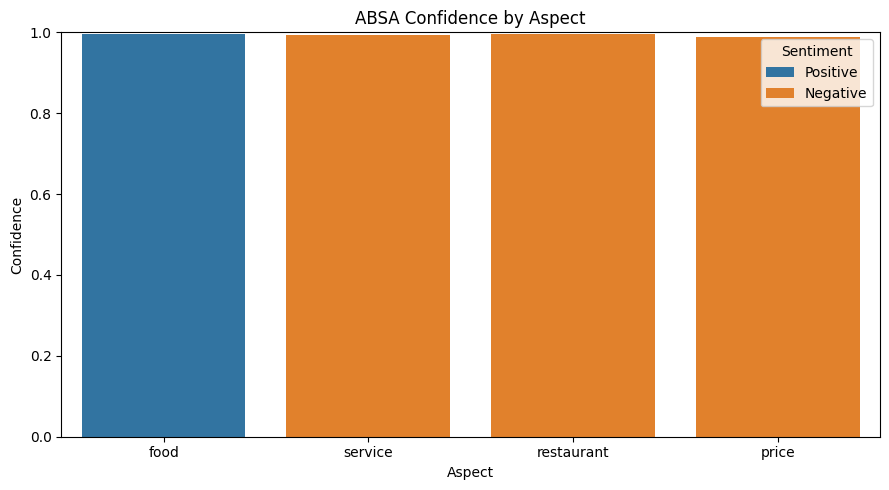

In [20]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=restaurant_df,
    x="Aspect",
    y="Confidence",
    hue="Sentiment",
    dodge=False
)

plt.ylim(0, 1)
plt.ylabel("Confidence")
plt.title("ABSA Confidence by Aspect")
plt.tight_layout()
plt.show()

##21. Student Prediction Challenge

In [21]:
challenge_sentence = (
    "The camera quality is excellent, the battery is terrible, "
    "and the phone design is beautiful."
)

challenge_aspects = ["camera quality", "battery", "phone design"]

print("Read the review before running the model:")
print(challenge_sentence)
print()
print("Try to predict:")
print("camera quality → ?")
print("battery → ?")
print("phone design → ?")
print()

challenge_result = analyze_aspects(
    challenge_sentence,
    challenge_aspects
)

challenge_result["Confidence %"] = (
    challenge_result["Confidence"] * 100
).round(2)

display(challenge_result[["Aspect", "Sentiment", "Confidence %"]])

Read the review before running the model:
The camera quality is excellent, the battery is terrible, and the phone design is beautiful.

Try to predict:
camera quality → ?
battery → ?
phone design → ?



,Aspect,Sentiment,Confidence %
0,camera quality,Positive,99.77
1,battery,Negative,99.11
2,phone design,Positive,99.35


##22. Interactive ABSA Input Demo

In [22]:
sentence = input("Enter a review: ")

aspects_input = input("Enter aspects separated by commas: ")

aspects = [
    aspect.strip()
    for aspect in aspects_input.split(",")
    if aspect.strip()
]

if not aspects:
    print("Please enter at least one aspect.")
else:
    interactive_df = analyze_aspects(sentence, aspects)
    interactive_df["Confidence %"] = (
        interactive_df["Confidence"] * 100
    ).round(2)

    display(interactive_df[["Aspect", "Sentiment", "Confidence %"]])

Enter a review: The pasta was delicious and fresh, but the waiter was rude and the price was too expensive.
Enter aspects separated by commas: pasta, waiter, price


,Aspect,Sentiment,Confidence %
0,pasta,Positive,99.74
1,waiter,Negative,99.62
2,price,Negative,99.64


##23. Standard BERT vs. ABSA Comparison

In [23]:
sentence = "I love chicken but hate KFC."

print("Sentence:")
print(sentence)

print("\n" + "=" * 70)
print("STANDARD BERT")
print("=" * 70)

overall = sentiment_pipeline(sentence)[0]

print("Overall sentiment:", overall["label"])
print("Confidence:", f"{overall['score']:.2%}")

print("\n" + "=" * 70)
print("ASPECT-BASED SENTIMENT ANALYSIS")
print("=" * 70)

comparison_df = analyze_aspects(sentence, ["chicken", "KFC"])
comparison_df["Confidence %"] = (
    comparison_df["Confidence"] * 100
).round(2)

display(comparison_df[["Aspect", "Sentiment", "Confidence %"]])

Sentence:
I love chicken but hate KFC.

STANDARD BERT
Overall sentiment: LABEL_0
Confidence: 98.26%

ASPECT-BASED SENTIMENT ANALYSIS


,Aspect,Sentiment,Confidence %
0,chicken,Positive,99.75
1,KFC,Negative,98.57


##24. Visual Comparison Diagram

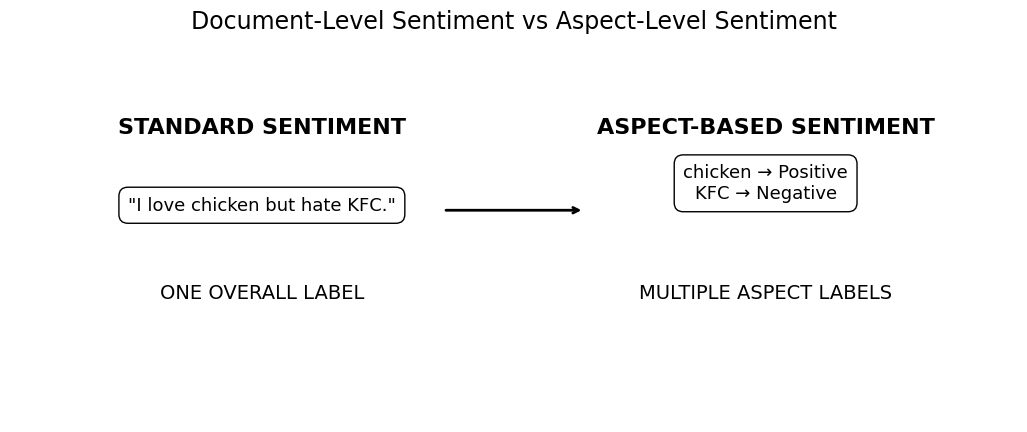

In [24]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")

ax.text(0.25, 0.75, "STANDARD SENTIMENT",
        ha="center", fontsize=16, fontweight="bold")

ax.text(
    0.25, 0.55,
    '"I love chicken but hate KFC."',
    ha="center", fontsize=13,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black")
)

ax.text(0.25, 0.32, "ONE OVERALL LABEL",
        ha="center", fontsize=14)

ax.text(0.75, 0.75, "ASPECT-BASED SENTIMENT",
        ha="center", fontsize=16, fontweight="bold")

ax.text(
    0.75, 0.58,
    "chicken → Positive\nKFC → Negative",
    ha="center", fontsize=13,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black")
)

ax.text(0.75, 0.32, "MULTIPLE ASPECT LABELS",
        ha="center", fontsize=14)

ax.annotate("", xy=(0.57, 0.55), xytext=(0.43, 0.55),
            arrowprops=dict(arrowstyle="->", lw=2))

plt.title("Document-Level Sentiment vs Aspect-Level Sentiment", fontsize=17)
plt.show()

##25. Verify spaCy English Model

In [25]:
print("spaCy pipeline:", nlp.pipe_names)
print("spaCy English model is ready.")

spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
spaCy English model is ready.


##26. Extract Candidate Aspects with spaCy

In [26]:
sentence = (
    "The camera is excellent, the battery is terrible, "
    "and the phone design is beautiful."
)

doc = nlp(sentence)

possible_aspects = []

for token in doc:
    if token.pos_ in ["NOUN", "PROPN"]:
        if token.text.lower() not in [
            aspect.lower() for aspect in possible_aspects
        ]:
            possible_aspects.append(token.text)

print("Sentence:")
print(sentence)

print("\nCandidate aspects:")
print(possible_aspects)

Sentence:
The camera is excellent, the battery is terrible, and the phone design is beautiful.

Candidate aspects:
['camera', 'battery', 'phone', 'design']


##27. Visualize POS Aspect Candidate Extraction

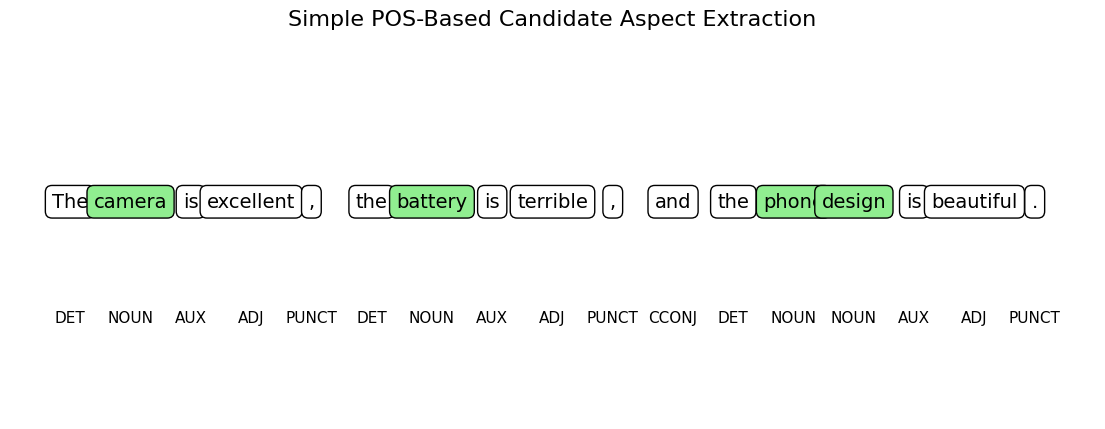

Green boxes = noun/proper-noun candidates


In [27]:
doc = nlp(sentence)

words = [token.text for token in doc]
pos_tags = [token.pos_ for token in doc]

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis("off")

for i, (word, pos) in enumerate(zip(words, pos_tags)):
    is_candidate = pos in ["NOUN", "PROPN"]

    ax.text(
        i, 0.55, word,
        ha="center", fontsize=14,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white" if not is_candidate else "lightgreen",
            edgecolor="black"
        )
    )

    ax.text(i, 0.25, pos, ha="center", fontsize=11)

ax.set_xlim(-1, len(words))
ax.set_ylim(0, 1)
ax.set_title("Simple POS-Based Candidate Aspect Extraction", fontsize=16)
plt.show()

print("Green boxes = noun/proper-noun candidates")

##28. Automatic ABSA Pipeline Function

In [28]:
def automatic_absa(sentence):
    doc = nlp(sentence)

    aspects = []
    seen = set()

    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"]:
            key = token.text.lower()
            if key not in seen:
                aspects.append(token.text)
                seen.add(key)

    results = []

    for aspect in aspects:
        prediction = absa_pipeline(
            sentence,
            text_pair=aspect
        )[0]

        results.append({
            "Aspect": aspect,
            "Sentiment": prediction["label"],
            "Confidence": prediction["score"]
        })

    return pd.DataFrame(
        results,
        columns=["Aspect", "Sentiment", "Confidence"]
    )

auto_result = automatic_absa(sentence)

if not auto_result.empty:
    auto_result["Confidence %"] = (
        auto_result["Confidence"] * 100
    ).round(2)
    display(auto_result[["Aspect", "Sentiment", "Confidence %"]])
else:
    print("No noun/proper-noun aspect candidates were found.")

,Aspect,Sentiment,Confidence %
0,camera,Positive,99.71
1,battery,Negative,99.16
2,phone,Positive,96.82
3,design,Positive,99.53


##29. Realistic Mixed Product Review Analysis

In [29]:
product_review = (
    "The laptop has an excellent display and a fast processor, "
    "but the battery life is disappointing and the keyboard feels cheap."
)

print("Review:")
print(product_review)

product_result = automatic_absa(product_review)

if len(product_result) > 0:
    product_result["Confidence %"] = (
        product_result["Confidence"] * 100
    ).round(2)

display(product_result[["Aspect", "Sentiment", "Confidence %"]])

Review:
The laptop has an excellent display and a fast processor, but the battery life is disappointing and the keyboard feels cheap.


,Aspect,Sentiment,Confidence %
0,laptop,Neutral,80.11
1,display,Positive,99.70
2,processor,Positive,99.62
3,battery,Negative,99.56
4,life,Negative,99.65
5,keyboard,Negative,99.60


##30. Manual vs. Automatic Aspect Comparison

In [30]:
manual_aspects = [
    "display",
    "processor",
    "battery life",
    "keyboard"
]

manual_result = analyze_aspects(
    product_review,
    manual_aspects
)

manual_result["Confidence %"] = (
    manual_result["Confidence"] * 100
).round(2)

display(manual_result[["Aspect", "Sentiment", "Confidence %"]])

,Aspect,Sentiment,Confidence %
0,display,Positive,99.70
1,processor,Positive,99.62
2,battery life,Negative,99.61
3,keyboard,Negative,99.60


##31. Final ABSA Dashboard Analysis

In [31]:
final_review = (
    "The food was delicious, the staff were friendly, "
    "but the service was slow and the prices were too high."
)

final_aspects = ["food", "staff", "service", "prices"]

final_result = analyze_aspects(
    final_review,
    final_aspects
)

final_result["Confidence %"] = (
    final_result["Confidence"] * 100
).round(2)

print("FINAL REVIEW")
print(final_review)

display(final_result[["Aspect", "Sentiment", "Confidence %"]])

FINAL REVIEW
The food was delicious, the staff were friendly, but the service was slow and the prices were too high.


,Aspect,Sentiment,Confidence %
0,food,Positive,99.69
1,staff,Positive,99.42
2,service,Negative,99.51
3,prices,Negative,99.51


##32. Final ABSA Dashboard Visualization

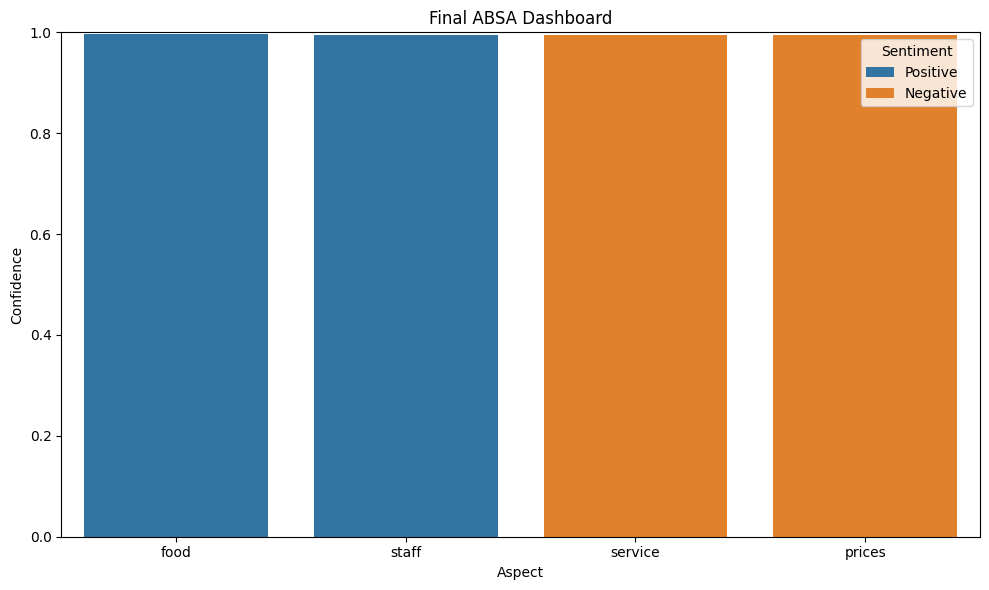

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_result,
    x="Aspect",
    y="Confidence",
    hue="Sentiment",
    dodge=False
)

plt.ylim(0, 1)
plt.xlabel("Aspect")
plt.ylabel("Confidence")
plt.title("Final ABSA Dashboard")
plt.tight_layout()
plt.show()

##33. End-to-End ABSA Workflow Diagram

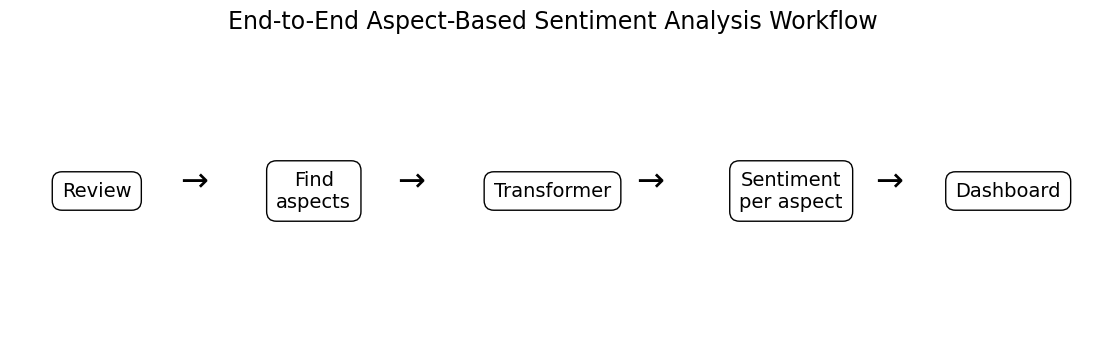

In [33]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")

steps = [
    ("Review", 0.08),
    ("Find\naspects", 0.28),
    ("Transformer", 0.50),
    ("Sentiment\nper aspect", 0.72),
    ("Dashboard", 0.92)
]

for label, x in steps:
    ax.text(
        x, 0.5, label,
        ha="center", va="center", fontsize=14,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black")
    )

for x in [0.18, 0.38, 0.60, 0.82]:
    ax.annotate("→", xy=(x + 0.035, 0.5), xytext=(x - 0.01, 0.5),
                fontsize=24, ha="center")

plt.title("End-to-End Aspect-Based Sentiment Analysis Workflow", fontsize=17)
plt.show()